# MAIE 5101: Programming for Artificial Intelligence
## Programming Assignment 2 - Exploratory Analysis and Data Pre-processing

## Description
In this assignment, you will have the opportunity to perform exploratory data analysis on the given dataset, apply data pre-processing techniques and machine learning techniques that you learned in class to a problem. 

To get started on this assignment, you need to download the given dataset and read the description carefully written on this page. Please note that all implementations should be done with Python.

The maximum score of this assignment is <strong>100 points</strong>.

<font color="red">*Late Submission Policy: There will be a penalty of -1% (i.e. -1 point) for every minute you are late.)*</a>

### Intended Learning Outcomes

Upon completion of this assignment, you should be able to:
<ol>
    <li>Demonstrate your understanding on how to pre-process data using the algorithms / techniques as described in the class.</li>
    <li>Use simple descriptive statistical appraoches to understand your data.</li>
    <li>Construct Python program to analyse the data and draw simple conclusions from it.</li>
</ol>

### Required Libraries
The following libraries are required for this assignment:
<ol>
    <li>Numpy - Numerical python</li>
    <li>Pandas - Python data analysis library</li>
    <li>Matplotlib - Python 2D plotting library</li>
</ol>

***Note: You can only use the above 3 libraries and the <a href="https://docs.python.org/3/library/index.html">standard Python libraries</a>. No other libraries can be used.***

### Dataset
The dataset contains daily weather observations from numerous Australian weather stations.
The problem is to predict whether or not it will rain tomorrow by training a binary classification model on target **RainTomorrow**.
The target variable **RainTomorrow** means: Will it rain the next day? Yes or No.

The list of features:
- Date - The date of observation.
- Location - Name of the city from Australia.
- MinTemp - The Minimum temperature during a particular day. (degree Celsius)
- MaxTemp - The maximum temperature during a particular day. (degree Celsius)
- Rainfall - Rainfall during a particular day. (millimeters)
- Evaporation - Evaporation during a particular day. (millimeters)
- Sunshine - Bright sunshine during a particular day. (hours)
- WindGusDir - The direction of the strongest gust during a particular day. (16 compass points)
- WindGuSpeed - Speed of strongest gust during a particular day. (kilometers per hour)
- WindDir9am - The direction of the wind for 10 min prior to 9 am. (compass points)
- WindDir3pm - The direction of the wind for 10 min prior to 3 pm. (compass points)
- WindSpeed9am - Speed of the wind for 10 min prior to 9 am. (kilometers per hour)
- WindSpeed3pm - Speed of the wind for 10 min prior to 3 pm. (kilometers per hour)
- Humidity9am - The humidity of the wind at 9 am. (percent)
- Humidity3pm - The humidity of the wind at 3 pm. (percent)
- Pressure9am - Atmospheric pressure at 9 am. (hectopascals)
- Pressure3pm - Atmospheric pressure at 3 pm. (hectopascals)
- Cloud9am - Cloud-obscured portions of the sky at 9 am. (eighths)
- Cloud3pm - Cloud-obscured portions of the sky at 3 pm. (eighths)
- Temp9am - The temperature at 9 am. (degree Celsius)
- Temp3pm - The temperature at 3 pm. (degree Celsius)
- RainToday - If today is rainy then ‘Yes’. If today is not rainy then ‘No’.
- RISK_MM - The amount of rain. A kind of measure of the "risk".
- RainTomorrow - If tomorrow is rainy then 1 (Yes). If tomorrow is not rainy then 0 (No).

Note: You should exclude the variable **Risk-MM** when training a binary classification model. Not excluding it will leak the answers to your model and reduce its predictive power. 

Read more about the dataset [here](https://r-packages.io/datasets/weatherAUS).

# Importing Libraries
Before we begin, let's import the libraries we need here.

This notebook serves as a way for you to quickly prototype your solutions; it is not graded. 

You should complete the required functions in `analysis.py`, which is imported by this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis as pa2

The following cell allows you to automatically reload changes to `analysis.py`. If this doesn't work for whatever reason, you should still be able to complete the assignment; however, you will need to restart Jupyter when you want to test your changes.

In [2]:
%load_ext autoreload
%autoreload 2

The following line enables CoW (copy-on-write) mode for Pandas. This means that changes to a view of a `DataFrame` will not modify the original dataset, and will instead create a copy. While this might be slightly cumbersome at first, it allows our code to be less prone to accidental side-effects caused by modifying a `DataFrame` in a function.

This is also the default mode for Pandas 3.0, so it is a good idea to get used to it now.

In [3]:
pd.options.mode.copy_on_write = True

C:\Windows\Temp\ipykernel_3404\856138102.py:1: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


# Part 1: Dataset Import & Feature Exploration (5 points)
In this part, we will read the dataset and explore some of the features it contains. Most of the tasks here are for your information and will not be graded; only functions which need to be implemented in `analysis.py` will be.

First, load the CSV file `weatherAUS.csv` and store it as `df`:

In [4]:
df = pd.read_csv("weatherAUS.csv")

Then, you can extract the shape, the first 10 and last 10 rows, and some summary information before working with the data.

While this is not graded, it is useful as a handy reference for what your dataset contains. You may refer back to this when completing the rest of the assignment.

Retrieve the shape of the dataset in the next cell:

In [5]:
df.shape

(266946, 24)

Get the first 10 rows in the next cell:

In [6]:
df.head(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,0.0,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,0.0,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,0.0,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,1.4,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,0.0,No


Get the last 10 rows in the next cell:

In [7]:
df.tail(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
266936,2025-07-21,Uluru,7.9,23.0,0.0,NaN,NaN,WNW,56.0,SSW,...,29.0,1011.8,1007.1,7.0,8.0,11.1,22.3,No,0.0,No
266937,2025-07-22,Uluru,0.1,15.8,0.0,NaN,NaN,S,43.0,SE,...,24.0,1018.9,1016.3,NaN,NaN,6.5,14.7,No,0.0,No
266938,2025-07-23,Uluru,-2.1,19.4,0.0,NaN,NaN,ENE,43.0,ESE,...,20.0,1019.9,1015.4,NaN,3.0,6.9,18.7,No,0.0,No
266939,2025-07-24,Uluru,6.9,26.8,0.0,NaN,NaN,NNW,74.0,E,...,29.0,1011.5,1004.7,2.0,2.0,12.0,25.4,No,24.0,Yes
266940,2025-07-25,Uluru,10.6,16.0,24.0,NaN,NaN,WSW,46.0,W,...,44.0,1010.6,1011.8,1.0,NaN,11.5,15.4,Yes,0.0,No
266941,2025-07-26,Uluru,3.2,15.7,0.0,NaN,NaN,SSW,37.0,SSW,...,38.0,1020.7,1018.3,6.0,NaN,8.6,14.4,No,0.0,No
266942,2025-07-27,Uluru,1.6,17.6,0.0,NaN,NaN,ENE,39.0,ESE,...,37.0,1021.1,1016.2,NaN,NaN,7.8,16.3,No,0.0,No
266943,2025-07-28,Uluru,7.8,22.5,0.0,NaN,NaN,WNW,54.0,NE,...,29.0,1010.4,1007.2,7.0,2.0,12.3,21.9,No,0.0,No
266944,2025-07-29,Uluru,7.0,17.2,0.0,NaN,NaN,SW,39.0,SW,...,28.0,1016.8,1015.6,NaN,NaN,10.2,16.3,No,0.0,No
266945,2025-07-30,Uluru,1.1,18.1,0.0,NaN,NaN,ENE,28.0,S,...,22.0,1022.6,1020.1,NaN,NaN,7.1,16.7,No,0.0,No


Generate a summary in the next cell (you can use `df.info`):

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           266946 non-null  str    
 1   Location       266946 non-null  str    
 2   MinTemp        262312 non-null  float64
 3   MaxTemp        262366 non-null  float64
 4   Rainfall       258920 non-null  float64
 5   Evaporation    113516 non-null  float64
 6   Sunshine       102736 non-null  float64
 7   WindGustDir    247166 non-null  str    
 8   WindGustSpeed  247366 non-null  float64
 9   WindDir9am     245935 non-null  str    
 10  WindDir3pm     255012 non-null  str    
 11  WindSpeed9am   261290 non-null  float64
 12  WindSpeed3pm   256721 non-null  float64
 13  Humidity9am    260749 non-null  float64
 14  Humidity3pm    255693 non-null  float64
 15  Pressure9am    237497 non-null  float64
 16  Pressure3pm    237518 non-null  float64
 17  Cloud9am       145301 non-null  float64


It is often useful to sample some random rows from your dataset. Complete the function `get_random_rows` in `analysis.py` to do so.

You should be able to see the results in the following cell after running it. Do not modify the following cell.

In [9]:
pa2.get_random_rows(df, 10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
193533,2014-05-28,Woomera,9.6,21.2,0.4,3.6,8.8,SW,28.0,W,...,44.0,1018.9,1017.7,1.0,3.0,13.6,20.9,No,0.0,No
228805,2020-07-06,SalmonGums,12.4,19.2,0.0,NaN,NaN,W,44.0,NNW,...,51.0,NaN,NaN,NaN,NaN,16.3,18.5,No,4.6,Yes
244771,2017-12-03,Launceston,7.4,15.2,60.0,NaN,NaN,SSE,48.0,SSE,...,79.0,NaN,NaN,8.0,8.0,8.0,12.6,Yes,7.6,Yes
230281,2024-07-21,SalmonGums,8.4,18.4,0.0,NaN,NaN,WNW,41.0,NW,...,55.0,NaN,NaN,NaN,NaN,12.4,18.2,No,0.0,No
144759,2014-05-20,Watsonia,14.3,21.2,0.2,4.2,2.9,SSW,30.0,NE,...,100.0,1020.0,1019.1,6.0,5.0,15.1,16.3,No,2.0,Yes
103621,2021-06-02,Ballarat,5.3,15.9,0.0,NaN,NaN,NNE,33.0,NNE,...,61.0,1019.1,1015.9,NaN,8.0,10.0,14.6,No,0.0,No
123893,2014-04-21,Melbourne,12.5,18.5,NaN,4.4,3.4,N,74.0,N,...,43.0,1019.4,1015.8,NaN,NaN,14.3,18.0,NaN,8.4,Yes
87517,2023-04-10,Canberra,0.7,16.5,0.0,NaN,NaN,N,35.0,SW,...,45.0,1010.1,1007.4,NaN,4.0,8.6,15.1,No,0.0,No
230355,2024-10-03,SalmonGums,9.9,20.1,3.0,NaN,NaN,WNW,72.0,WNW,...,41.0,NaN,NaN,NaN,NaN,14.8,18.8,Yes,0.0,No
69292,2020-05-09,WaggaWagga,8.8,18.4,NaN,NaN,NaN,W,57.0,SW,...,74.0,1011.8,1012.0,7.0,8.0,12.4,14.0,NaN,NaN,NaN


It is also important that we know what types our features actually are. Complete the function `count_feature_types` in `analysis.py` to find out.

The function should return a tuple of two lists of strings; the first list should contain the names of all numerical features, the second list should contain the names of all categorical features.

You should be able to see the results after implementing the function and running the following cell. Do not modify it.

In [10]:
num_feats, cat_feats = pa2.count_feature_types(df)
print(f"There are {len(num_feats)} numerical features, which are: {num_feats}")
print(f"There are {len(cat_feats)} categorical features, which are: {cat_feats}")

There are 17 numerical features, which are: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RISK_MM']
There are 7 categorical features, which are: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


# Part 2: Data Transformation (25 points)
If you observe the data types of our dataset, you will notice that all non-numerical data types are `object`, and all numerical data types are `float64`. However, some of these types can definitely be represented in other, more meaningful ways.

Here are some examples:
- The `Date` feature can be represented as a `datetime` object from Pandas to allow us to sort by it.
    - We can also take this further and create `Day`, `Month`, `Year`, and even `Season` features for us to analyse!
- The `RainToday` and `RainTomorrow` only store Yes / No values. They can be represented as a `bool` to save on space.
- The `Cloud9am` and `Cloud3pm` features can only contain integers from 1 to 9. They can be converted into a categorical variable for ease of representation.
    - Some background knowledge: `Cloud9am` is the cloud cover at 9 am, and `Cloud3pm` is the cloud cover at 3pm. Cloud cover is measured visually by estimating the fraction (in eighths, or oktas) of the dome of the sky covered by cloud. A completely clear sky is recorded as zero oktas, while a totally overcast sky is 8 oktas. There is an additional indicator '9' indicating that the sky is totally obscured (i.e. hidden from view).

This is not an exhaustive list, and there are more transforms we can do to make the dataset more useful.

Now, we are going to run through these transformations below by completing the appropriate functions in `analysis.py`.

## `Cloud9am` & `Cloud3pm`
First, let's handle `Cloud9am` and `Cloud3pm`. From the background knowledge, we know that it is a categorical variable. Complete the function `convert_to_categorical` in `analysis.py` to change these two features to a categorical feature. Your function should modify the input `DataFrame`, and return the modified dataset for function chaining.

After finishing the function, you should be able to run the cell to see the result.

In [11]:
pa2.convert_to_categorical(df, ["Cloud9am", "Cloud3pm"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   Date           266946 non-null  str     
 1   Location       266946 non-null  str     
 2   MinTemp        262312 non-null  float64 
 3   MaxTemp        262366 non-null  float64 
 4   Rainfall       258920 non-null  float64 
 5   Evaporation    113516 non-null  float64 
 6   Sunshine       102736 non-null  float64 
 7   WindGustDir    247166 non-null  str     
 8   WindGustSpeed  247366 non-null  float64 
 9   WindDir9am     245935 non-null  str     
 10  WindDir3pm     255012 non-null  str     
 11  WindSpeed9am   261290 non-null  float64 
 12  WindSpeed3pm   256721 non-null  float64 
 13  Humidity9am    260749 non-null  float64 
 14  Humidity3pm    255693 non-null  float64 
 15  Pressure9am    237497 non-null  float64 
 16  Pressure3pm    237518 non-null  float64 
 17  Cloud9am       145301

You will note that this has changed the **original** dataset object as well:

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   Date           266946 non-null  str     
 1   Location       266946 non-null  str     
 2   MinTemp        262312 non-null  float64 
 3   MaxTemp        262366 non-null  float64 
 4   Rainfall       258920 non-null  float64 
 5   Evaporation    113516 non-null  float64 
 6   Sunshine       102736 non-null  float64 
 7   WindGustDir    247166 non-null  str     
 8   WindGustSpeed  247366 non-null  float64 
 9   WindDir9am     245935 non-null  str     
 10  WindDir3pm     255012 non-null  str     
 11  WindSpeed9am   261290 non-null  float64 
 12  WindSpeed3pm   256721 non-null  float64 
 13  Humidity9am    260749 non-null  float64 
 14  Humidity3pm    255693 non-null  float64 
 15  Pressure9am    237497 non-null  float64 
 16  Pressure3pm    237518 non-null  float64 
 17  Cloud9am       145301

## `Location`, `WindGustDir`, `WindDir9am` & `WindDir3pm`
Likewise, we can convert the following features to categorical features by reusing our original function:

In [13]:
pa2.convert_to_categorical(df, ["Location", "WindGustDir", "WindDir9am", "WindDir3pm"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   Date           266946 non-null  str     
 1   Location       266946 non-null  category
 2   MinTemp        262312 non-null  float64 
 3   MaxTemp        262366 non-null  float64 
 4   Rainfall       258920 non-null  float64 
 5   Evaporation    113516 non-null  float64 
 6   Sunshine       102736 non-null  float64 
 7   WindGustDir    247166 non-null  category
 8   WindGustSpeed  247366 non-null  float64 
 9   WindDir9am     245935 non-null  category
 10  WindDir3pm     255012 non-null  category
 11  WindSpeed9am   261290 non-null  float64 
 12  WindSpeed3pm   256721 non-null  float64 
 13  Humidity9am    260749 non-null  float64 
 14  Humidity3pm    255693 non-null  float64 
 15  Pressure9am    237497 non-null  float64 
 16  Pressure3pm    237518 non-null  float64 
 17  Cloud9am       145301

## `RainToday` & `RainTomorrow`
Then, we should be able to handle the `RainToday` and `RainTomorrow` features by converting them to a `bool` Series instead of `str` values of Yes / No. Complete the function `convert_rain` in `analysis.py` to accomplish this. As before, you should modify the input `DataFrame`, and return the modified dataset for function chaining.

Do note that if you run this cell twice, you *may* convert everything to `True` / `False` depending on your implementation. Handling this case specifically is advised to prevent you from making accidents, though not required.

After finishing the function, you should be able to run the cell to see the result.

In [14]:
pa2.convert_rain(df).info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   Date           266946 non-null  str     
 1   Location       266946 non-null  category
 2   MinTemp        262312 non-null  float64 
 3   MaxTemp        262366 non-null  float64 
 4   Rainfall       258920 non-null  float64 
 5   Evaporation    113516 non-null  float64 
 6   Sunshine       102736 non-null  float64 
 7   WindGustDir    247166 non-null  category
 8   WindGustSpeed  247366 non-null  float64 
 9   WindDir9am     245935 non-null  category
 10  WindDir3pm     255012 non-null  category
 11  WindSpeed9am   261290 non-null  float64 
 12  WindSpeed3pm   256721 non-null  float64 
 13  Humidity9am    260749 non-null  float64 
 14  Humidity3pm    255693 non-null  float64 
 15  Pressure9am    237497 non-null  float64 
 16  Pressure3pm    237518 non-null  float64 
 17  Cloud9am       145301

## `Date`
Finally, it is time to tackle the transformation of `Date`.

First, we want to transform `Date` into a Pandas `datetime` Series. Complete the function `convert_to_datetime` in `analysis.py` to do so.

You can run the cell after doing so to check the result.

In [15]:
pa2.convert_to_datetime(df).info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           266946 non-null  datetime64[us]
 1   Location       266946 non-null  category      
 2   MinTemp        262312 non-null  float64       
 3   MaxTemp        262366 non-null  float64       
 4   Rainfall       258920 non-null  float64       
 5   Evaporation    113516 non-null  float64       
 6   Sunshine       102736 non-null  float64       
 7   WindGustDir    247166 non-null  category      
 8   WindGustSpeed  247366 non-null  float64       
 9   WindDir9am     245935 non-null  category      
 10  WindDir3pm     255012 non-null  category      
 11  WindSpeed9am   261290 non-null  float64       
 12  WindSpeed3pm   256721 non-null  float64       
 13  Humidity9am    260749 non-null  float64       
 14  Humidity3pm    255693 non-null  float64       
 15  Pressure9am

Then, we can further split the `Date` series into `Day`, `Month` and `Year` components. Complete the function `split_datetime` in `analysis.py` to add the `Day`, `Month` and `Year` Series to the original DataFrame.

Run the following cells to check the output of your function:

In [16]:
pa2.split_datetime(df).info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           266946 non-null  datetime64[us]
 1   Location       266946 non-null  category      
 2   MinTemp        262312 non-null  float64       
 3   MaxTemp        262366 non-null  float64       
 4   Rainfall       258920 non-null  float64       
 5   Evaporation    113516 non-null  float64       
 6   Sunshine       102736 non-null  float64       
 7   WindGustDir    247166 non-null  category      
 8   WindGustSpeed  247366 non-null  float64       
 9   WindDir9am     245935 non-null  category      
 10  WindDir3pm     255012 non-null  category      
 11  WindSpeed9am   261290 non-null  float64       
 12  WindSpeed3pm   256721 non-null  float64       
 13  Humidity9am    260749 non-null  float64       
 14  Humidity3pm    255693 non-null  float64       
 15  Pressure9am

In [17]:
df.tail(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Day,Month,Year
266936,2025-07-21,Uluru,7.9,23.0,0.0,NaN,NaN,WNW,56.0,SSW,...,7.0,8.0,11.1,22.3,False,0.0,False,21,7,2025
266937,2025-07-22,Uluru,0.1,15.8,0.0,NaN,NaN,S,43.0,SE,...,NaN,NaN,6.5,14.7,False,0.0,False,22,7,2025
266938,2025-07-23,Uluru,-2.1,19.4,0.0,NaN,NaN,ENE,43.0,ESE,...,NaN,3.0,6.9,18.7,False,0.0,False,23,7,2025
266939,2025-07-24,Uluru,6.9,26.8,0.0,NaN,NaN,NNW,74.0,E,...,2.0,2.0,12.0,25.4,False,24.0,True,24,7,2025
266940,2025-07-25,Uluru,10.6,16.0,24.0,NaN,NaN,WSW,46.0,W,...,1.0,NaN,11.5,15.4,True,0.0,False,25,7,2025
266941,2025-07-26,Uluru,3.2,15.7,0.0,NaN,NaN,SSW,37.0,SSW,...,6.0,NaN,8.6,14.4,False,0.0,False,26,7,2025
266942,2025-07-27,Uluru,1.6,17.6,0.0,NaN,NaN,ENE,39.0,ESE,...,NaN,NaN,7.8,16.3,False,0.0,False,27,7,2025
266943,2025-07-28,Uluru,7.8,22.5,0.0,NaN,NaN,WNW,54.0,NE,...,7.0,2.0,12.3,21.9,False,0.0,False,28,7,2025
266944,2025-07-29,Uluru,7.0,17.2,0.0,NaN,NaN,SW,39.0,SW,...,NaN,NaN,10.2,16.3,False,0.0,False,29,7,2025
266945,2025-07-30,Uluru,1.1,18.1,0.0,NaN,NaN,ENE,28.0,S,...,NaN,NaN,7.1,16.7,False,0.0,False,30,7,2025


It might help to display `Month` in a more human-readable format as well. We should convert the `Month` Series to store values such as `"January", "Feburary", ...` as an ordered categorical variable. These values should be ordered in ascending order, i.e. `"January" < "Feburary" < "March" < ...`.

Complete the function `convert_month` in `analysis.py` to complete the task above. You should be able to check your output in the following cells:

In [18]:
pa2.convert_month(df).info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           266946 non-null  datetime64[us]
 1   Location       266946 non-null  category      
 2   MinTemp        262312 non-null  float64       
 3   MaxTemp        262366 non-null  float64       
 4   Rainfall       258920 non-null  float64       
 5   Evaporation    113516 non-null  float64       
 6   Sunshine       102736 non-null  float64       
 7   WindGustDir    247166 non-null  category      
 8   WindGustSpeed  247366 non-null  float64       
 9   WindDir9am     245935 non-null  category      
 10  WindDir3pm     255012 non-null  category      
 11  WindSpeed9am   261290 non-null  float64       
 12  WindSpeed3pm   256721 non-null  float64       
 13  Humidity9am    260749 non-null  float64       
 14  Humidity3pm    255693 non-null  float64       
 15  Pressure9am

In [19]:
print(f"The dtype of the Month feature is: {df["Month"].dtype}.")
print(f"The categories of the Month feature are: {list(df["Month"].cat.categories)}.")
print(f"Is the feature ordered? {df["Month"].cat.ordered}")

The dtype of the Month feature is: category.
The categories of the Month feature are: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'].
Is the feature ordered? True


Finally, we can add a `Season` feature to group our data. This allows us to easily analyse the data by season instead of by months only.

In this assignment, we will follow the "meteorological seasons" approach. The definition of "meteorological seasons" refers to the partition of a year into four periods of roughly equal length (i.e. three months as a period). 

For the Northern Hemisphere, the warmest and coldest periods are respectively designated as Summer (June, July and August) and Winter (December, January and February), and the in-between periods as Autumn (September, October and November) and Spring (March, April and May). 

However, our dataset is from Australia. Can you figure out what the appropriate mapping is?

Complete the function `month_to_season` in `analysis.py` to map integers which represent months into the appropriate season. The seasons are represented as uppercase strings (i.e. `"Summer"`, `"Winter"`, etc.).

The following cell contains some test cases for your code:

In [20]:
print(f"The season for December is: {pa2.month_to_season(12)}")
print(f"The season for July is: {pa2.month_to_season(7)}")
print(f"The season for October is: {pa2.month_to_season(10)}")

The season for December is: Summer
The season for July is: Winter
The season for October is: Spring


Finally, we can create the `Season` categorical variable based on `Date`. Complete the function `add_season_feature` in `analysis.py` to do so. The following cell allows you to test your code:

In [21]:
pa2.add_season_feature(df).info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 28 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           266946 non-null  datetime64[us]
 1   Location       266946 non-null  category      
 2   MinTemp        262312 non-null  float64       
 3   MaxTemp        262366 non-null  float64       
 4   Rainfall       258920 non-null  float64       
 5   Evaporation    113516 non-null  float64       
 6   Sunshine       102736 non-null  float64       
 7   WindGustDir    247166 non-null  category      
 8   WindGustSpeed  247366 non-null  float64       
 9   WindDir9am     245935 non-null  category      
 10  WindDir3pm     255012 non-null  category      
 11  WindSpeed9am   261290 non-null  float64       
 12  WindSpeed3pm   256721 non-null  float64       
 13  Humidity9am    260749 non-null  float64       
 14  Humidity3pm    255693 non-null  float64       
 15  Pressure9am

# Part 3: Data Distribution Exploration (20 points)
After creating some features, we can now explore the distribution of data in our dataset more effectively!

Most of these tasks are again not assessed; they are provided for you to learn about common ways to quickly explore data. Only functions completed in `analysis.py` will be graded.

First, we want to have an idea of how many cities are included in the dataset. Find the counts of each city in `Location` below:

In [22]:
df["Location"].value_counts()

Location
Canberra            5994
Sydney              5902
Brisbane            5751
Darwin              5751
Hobart              5751
Melbourne           5751
Perth               5750
Albury              5598
AliceSprings        5598
Cairns              5598
GoldCoast           5598
Launceston          5598
Townsville          5598
Wollongong          5598
Albany              5597
MountGambier        5597
Penrith             5597
Tuggeranong         5597
Ballarat            5596
Bendigo             5589
MountGinini         5586
Cobar               5567
CoffsHarbour        5567
Dartmoor            5567
MelbourneAirport    5567
Mildura             5567
Moree               5567
NorfolkIsland       5567
Portland            5567
Richmond            5567
Sale                5567
SydneyAirport       5567
WaggaWagga          5567
Watsonia            5567
Williamtown         5567
Woomera             5567
Nuriootpa           5566
PearceRAAF          5566
PerthAirport        5566
Walpole         

Then, we want to know the number of seasons included. Print a summary below:

In [23]:
df["Season"].value_counts()

Season
Winter    69060
Autumn    68834
Spring    65695
Summer    63357
Name: count, dtype: int64

We can also plot a histogram:

<Axes: xlabel='Season'>

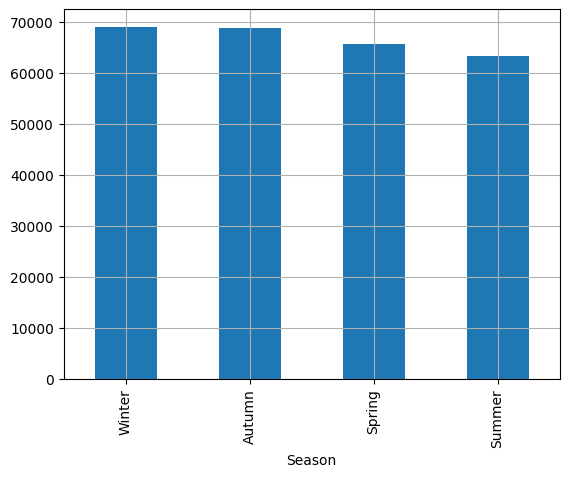

In [24]:
df["Season"].value_counts().plot.bar(grid=True)

Next, we're going to analyse the relationship between two pairs of variables: `Month` & `RainTomorrow`, and `Season` & `Rainfall`.

## `Month` & `RainTomorrow`
To analyse the relationship between `Month` and `RainTomorrow`, we can group our data by month and count the number of days with and without rain on the next day.

We can convert the data into a `DataFrame` with two columns: `HasRainTomorrow` and `NoRainTomorrow`. Each row in the `DataFrame` corresponds to the total count of days with or without rain.

Complete the function `compute_monthly_rain_days` in `analysis.py` to create the `DataFrame` mentioned above.

You can use the following cell to check your answers:

In [25]:
month_rain_summary = pa2.compute_monthly_rain_days(df)
month_rain_summary

,HasRainTomorrow,NoRainTomorrow
Month,,
January,4289,18975
February,3761,14975
March,5052,18624
April,4437,17076
May,5060,18585
June,5593,17296
July,6044,17745
August,5348,17034
September,4458,17202


Now that we have the data, we can plot it in a stacked bar plot. The x-axis of such a plot is the month, and the y-axis is the number of days.

Complete the function `plot_rain_distrib` in `analysis.py` to create a plot using `matplotlib`. The function should return a tuple of the figure and axis of the stacked bar plot. The `HasRainTomorrow` attribute should be plotted below `NoRainTomorrow`.

Use the cell below to test your code:

d:\Desktop\ASSN\Semester 2\PAI\ASSN2\maie5101-pa2\skeleton\analysis.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(months, rotation=45, ha="right")


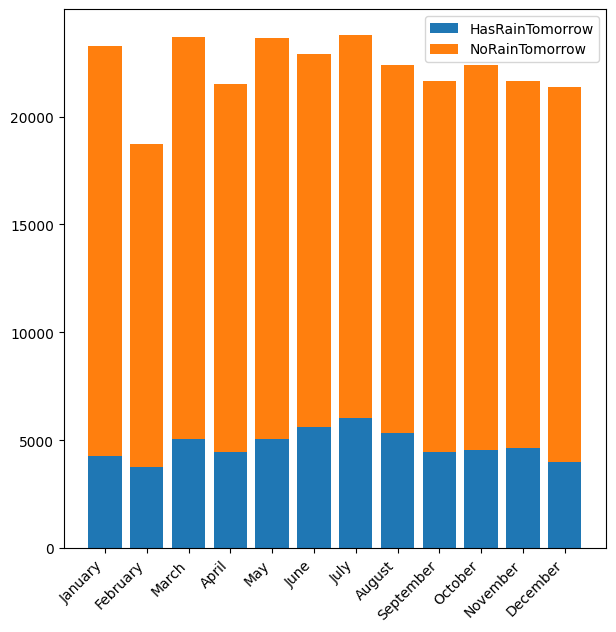

In [26]:
fig, ax = pa2.plot_rain_distrib(month_rain_summary)
plt.show()

## `Season` & `Rainfall`
We can also calculate the total rainfall per season using our new `Season` feature. 

This time, we can group our data by `Season` and calculate the sum of all rainfall. Since we are only obtaining one value per season, we can return a `Series` instead of a `DataFrame`.

Complete the function `compute_seasonal_rainfall` in `analysis.py` to generate the aggregate data. You can use the following cell to check your results.

In [27]:
rainfall_series = pa2.compute_seasonal_rainfall(df)
rainfall_series

Season
Summer    171309.8
Autumn    164666.4
Winter    145754.7
Spring    124344.2
Name: Rainfall, dtype: float64

As before, you can create a bar chart to display this data in the cell below. In this case, the x-axis is the seasons, and the y-axis is the total rainfall.

C:\Windows\Temp\ipykernel_3404\3587582556.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rainfall_series.index, rotation=45, ha="right")


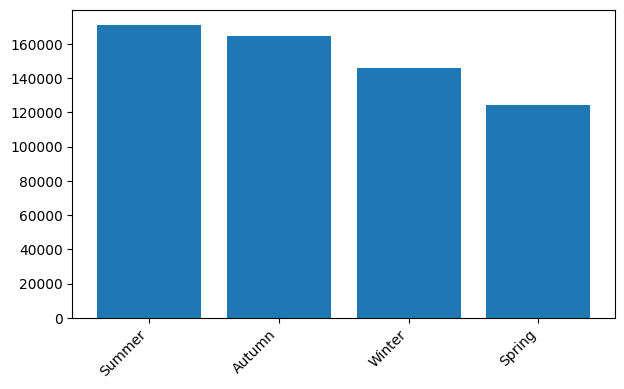

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rainfall_series.index, rainfall_series.values)
ax.set_xticklabels(rainfall_series.index, rotation=45, ha="right")
plt.show()

# Part 4: Outlier Detection and Removal (15 points)
While we have computed some summary statistics between different variables in the previous part, we have not actually taken a look at the quartiles of our data.
Let's take a look using `DataFrame.describe`.

In [29]:
df.describe(include=np.number)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RISK_MM,Day,Year
count,262312.000000,262366.000000,258920.000000,113516.000000,102736.000000,247366.000000,261290.000000,256721.000000,260749.000000,255693.000000,237497.000000,237518.000000,262336.000000,257164.00000,258920.000000,266946.000000,266946.000000
mean,12.080675,23.222863,2.340781,5.487237,7.618571,39.902101,14.010020,18.490521,69.236576,51.561877,1017.735859,1015.304496,16.901198,21.71396,2.341325,15.719606,2016.862092
std,6.431893,7.121094,8.601249,4.147866,3.773884,13.488690,8.829348,8.671325,19.365645,21.005646,7.084666,7.040734,6.530025,6.98586,8.602643,8.796981,4.953268
min,-8.700000,-4.100000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,978.600000,972.000000,-6.200000,-5.10000,0.000000,1.000000,2007.000000
25%,7.500000,18.000000,0.000000,2.700000,4.800000,31.000000,7.000000,13.000000,57.000000,36.000000,1013.000000,1010.400000,12.200000,16.60000,0.000000,8.000000,2013.000000
50%,11.900000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,17.000000,70.000000,52.000000,1017.700000,1015.200000,16.600000,21.20000,0.000000,16.000000,2017.000000
75%,16.700000,28.200000,0.600000,7.400000,10.600000,48.000000,19.000000,24.000000,84.000000,66.000000,1022.600000,1020.200000,21.500000,26.50000,0.600000,23.000000,2021.000000
max,33.900000,48.900000,474.000000,138.700000,14.500000,154.000000,87.000000,87.000000,100.000000,100.000000,1042.500000,1040.300000,40.200000,48.20000,474.000000,31.000000,2025.000000


As you can see, there are some extreme values in many of our features. One way to improve the reliability of our model is to remove them somehow.

There are two common approaches to removing outliers in general:
- **Removal (Filtering)**:
    - Remove all data points which lie outside some predefined range.
    - Pros: Does not affect the data distribution.
    - Cons: Reduces the sample size and may discard useful data.
- **Capping (Trimming / Winsorizing)**:
    - Replace values beyond the bounds with the nearest valid threshold (i.e., lower or upper bound value).
    - Pros: The size of the dataset is preserved, allowing you to use most of your collected data.
    - Cons: Can distort original values or mask meaningful extremes.

In this part, we will cap the values to a predefined valid threshold. However, you are free to experiment with other strategies if you have time to do so.

First, we need to identify which features have outliers. We will use the 1.5 IQR rule to aid with this process.

The 1.5 IQR rule is a widely used method for identifying outliers in a dataset, where any data point that lies more than 1.5 times the interquartile range (IQR) above the third quartile (Q3) or below the first quartile (Q1) is considered an outlier.

Complete the function `find_outlier_features` in `analysis.py` to find the names of all features with outliers using the 1.5 IQR rule. The function should also accept a list of features which should be excluded from this calculation. You can check your answer using the cell below.

In [30]:
outliers = pa2.find_outlier_features(df, ["RISK_MM", "Day", "Month", "Year"])
print(f"There are {len(outliers)} outliers, which are {outliers}.")

There are 12 outliers, which are ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'].


Now that you have the outliers, you can cap them accordingly. Complete the function `cap_outliers` in `analysis.py`, which caps the input numerical features to the following range:
$$[-1.5 * \text{IQR} + \text{LQ}, \text{UQ} + 1.5 * \text{IQR}]$$

You can test your code using the cell below.

In [31]:
pa2.cap_outliers(df, outliers)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Day,Month,Year,Season
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,NaN,16.9,21.8,False,0.0,False,1,December,2008,Summer
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,NaN,17.2,24.3,False,0.0,False,2,December,2008,Summer
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,2.0,21.0,23.2,False,0.0,False,3,December,2008,Summer
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,NaN,18.1,26.5,False,1.0,False,4,December,2008,Summer
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,8.0,17.8,29.7,False,0.2,False,5,December,2008,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266941,2025-07-26,Uluru,3.2,15.7,0.0,NaN,NaN,SSW,37.0,SSW,...,NaN,8.6,14.4,False,0.0,False,26,July,2025,Winter
266942,2025-07-27,Uluru,1.6,17.6,0.0,NaN,NaN,ENE,39.0,ESE,...,NaN,7.8,16.3,False,0.0,False,27,July,2025,Winter
266943,2025-07-28,Uluru,7.8,22.5,0.0,NaN,NaN,WNW,54.0,NE,...,2.0,12.3,21.9,False,0.0,False,28,July,2025,Winter
266944,2025-07-29,Uluru,7.0,17.2,0.0,NaN,NaN,SW,39.0,SW,...,NaN,10.2,16.3,False,0.0,False,29,July,2025,Winter


# Part 5: Handling Missing Values (10 points)
One thing you might have noticed is that some of our data is missing. Real-world data is often incomplete, and our dataset is no exception. Pandas has automatically filled in some of the missing data with NaN, but we can do better than that.

One way to remove NaNs is to fill them in with some value which represents the mean or the most common data. This process is known as **imputation**.

In our case, we will use mean to impute the numerical features, and mode to impute the categorical features.

Implement `impute_data` in `analysis.py` to fill in the missing values according to the rules above. After this, there should be no more missing values in the DataFrame.

You can check your answer by running the cells below.

In [32]:
pa2.impute_data(df)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Day,Month,Year,Season
0,2008-12-01,Albury,13.4,22.9,0.6,5.337031,7.618571,W,44.0,W,...,7.0,16.9,21.8,False,0.0,False,1,December,2008,Summer
1,2008-12-02,Albury,7.4,25.1,0.0,5.337031,7.618571,WNW,44.0,NNW,...,7.0,17.2,24.3,False,0.0,False,2,December,2008,Summer
2,2008-12-03,Albury,12.9,25.7,0.0,5.337031,7.618571,WSW,46.0,W,...,2.0,21.0,23.2,False,0.0,False,3,December,2008,Summer
3,2008-12-04,Albury,9.2,28.0,0.0,5.337031,7.618571,NE,24.0,SE,...,7.0,18.1,26.5,False,1.0,False,4,December,2008,Summer
4,2008-12-05,Albury,17.5,32.3,1.0,5.337031,7.618571,W,41.0,ENE,...,8.0,17.8,29.7,False,0.2,False,5,December,2008,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266941,2025-07-26,Uluru,3.2,15.7,0.0,5.337031,7.618571,SSW,37.0,SSW,...,7.0,8.6,14.4,False,0.0,False,26,July,2025,Winter
266942,2025-07-27,Uluru,1.6,17.6,0.0,5.337031,7.618571,ENE,39.0,ESE,...,7.0,7.8,16.3,False,0.0,False,27,July,2025,Winter
266943,2025-07-28,Uluru,7.8,22.5,0.0,5.337031,7.618571,WNW,54.0,NE,...,2.0,12.3,21.9,False,0.0,False,28,July,2025,Winter
266944,2025-07-29,Uluru,7.0,17.2,0.0,5.337031,7.618571,SW,39.0,SW,...,7.0,10.2,16.3,False,0.0,False,29,July,2025,Winter


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266946 entries, 0 to 266945
Data columns (total 28 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           266946 non-null  datetime64[us]
 1   Location       266946 non-null  category      
 2   MinTemp        266946 non-null  float64       
 3   MaxTemp        266946 non-null  float64       
 4   Rainfall       266946 non-null  float64       
 5   Evaporation    266946 non-null  float64       
 6   Sunshine       266946 non-null  float64       
 7   WindGustDir    266946 non-null  category      
 8   WindGustSpeed  266946 non-null  float64       
 9   WindDir9am     266946 non-null  category      
 10  WindDir3pm     266946 non-null  category      
 11  WindSpeed9am   266946 non-null  float64       
 12  WindSpeed3pm   266946 non-null  float64       
 13  Humidity9am    266946 non-null  float64       
 14  Humidity3pm    266946 non-null  float64       
 15  Pressure9am

# Part 6: Correlation Analysis (15 points)
Now that we have imputed all the missing data, we can use the dataset to figure out which features are the most correlated with one another.

It is often useful to display the correlation matrix as a heatmap.

The following attributes should be excluded from our calculations for various reasons:
- `RISK_MM`
- `Date`

Complete the function `plot_corr_heatmap` in `analysis.py`. The function should create a heatmap of the correlation between **only numerical features** using `matplotlib`. The features mentioned above should be excluded.

Use the cell below to test your code.

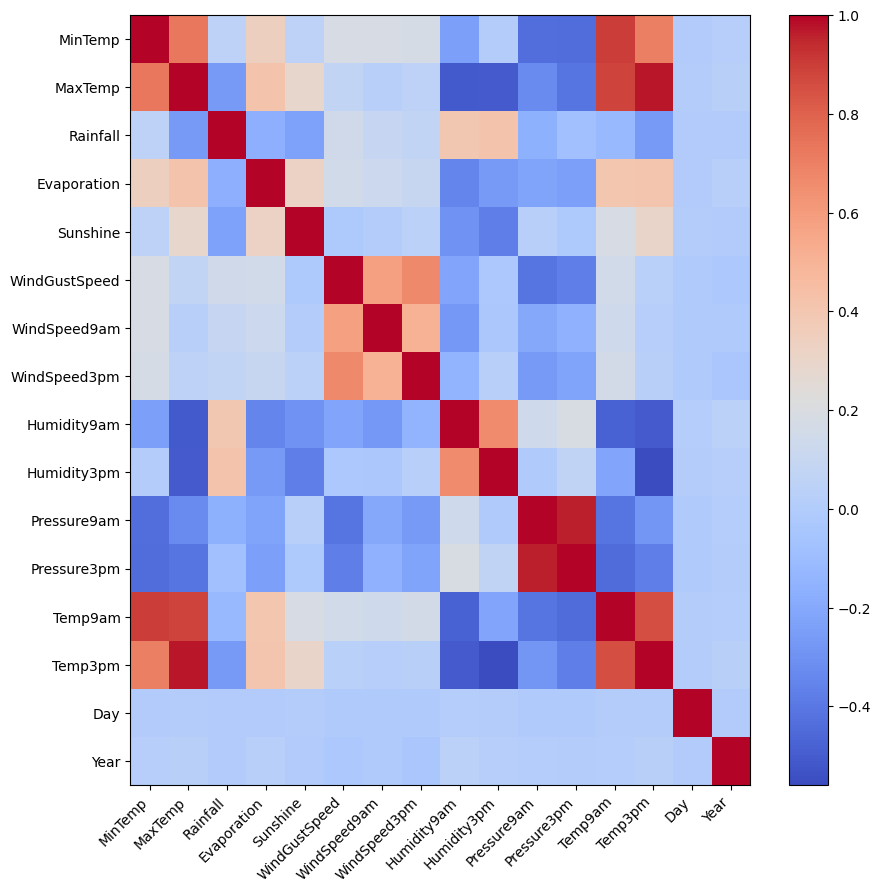

In [34]:
fig, ax = pa2.plot_corr_heatmap(df)
plt.show()

Now that you have some idea about the correlation between features, you can select features which are the most correlated for training machine learning models.

Complete the function `select_k_best` in `analysis.py`. The function should select `k` numerical features which are the most correlated with an input feature. You may assume that the input must be a numerical feature, and `k` will not be larger than the number of features. Remember to drop `Date` and `RISK_MM`!

Run the cells below to check your results.

In [35]:
pa2.select_k_best(df, "MaxTemp", 4)

['Temp3pm', 'Temp9am', 'MinTemp', 'Humidity9am']

In [36]:
pa2.select_k_best(df, "WindGustSpeed", 2)

['WindSpeed3pm', 'WindSpeed9am']

# Part 7: Skewness and Normalization (10 points)
Now that we can correctly select the most correlated features from our dataset, our task is technically done. However, the following two parts give you some additional methods of handling data which might prove useful when you want to improve the accuracy of your model.

Skewness of features can often impact any models we train. One common technique is to apply a log transformation (i.e. `log(x + 1)`) for all the data in the feature `x` **if the data is right-skewed**.

First, we should identify what features are skewed. Complete the function `find_right_skewed` in `analysis.py` to return the right-skewed features (those with skewness > 0.5) and their skew value. You should ignore boolean features and non-numeric features.

Run the cell below to test your implementation.

In [37]:
pa2.find_right_skewed(df)

Rainfall          1.165862
Evaporation       1.200110
WindGustSpeed     0.583288
WindSpeed9am      0.510930
RISK_MM          10.744553
dtype: float64

Now that we have the list of skewed features, we can apply our transform. Complete the function `apply_log_transform` in `analysis.py` to apply log transformation to all right-skewed features.

Note that this will alter your DataFrame, so you cannot re-run the cells above to obtain the same results.

Run the cell below to test your code.

In [38]:
pa2.apply_log_transform(df)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Day,Month,Year,Season
0,2008-12-01,Albury,13.4,22.9,0.470004,1.84641,7.618571,W,3.806662,W,...,7.0,16.9,21.8,False,0.000000,False,1,December,2008,Summer
1,2008-12-02,Albury,7.4,25.1,0.000000,1.84641,7.618571,WNW,3.806662,NNW,...,7.0,17.2,24.3,False,0.000000,False,2,December,2008,Summer
2,2008-12-03,Albury,12.9,25.7,0.000000,1.84641,7.618571,WSW,3.850148,W,...,2.0,21.0,23.2,False,0.000000,False,3,December,2008,Summer
3,2008-12-04,Albury,9.2,28.0,0.000000,1.84641,7.618571,NE,3.218876,SE,...,7.0,18.1,26.5,False,0.693147,False,4,December,2008,Summer
4,2008-12-05,Albury,17.5,32.3,0.693147,1.84641,7.618571,W,3.737670,ENE,...,8.0,17.8,29.7,False,0.182322,False,5,December,2008,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266941,2025-07-26,Uluru,3.2,15.7,0.000000,1.84641,7.618571,SSW,3.637586,SSW,...,7.0,8.6,14.4,False,0.000000,False,26,July,2025,Winter
266942,2025-07-27,Uluru,1.6,17.6,0.000000,1.84641,7.618571,ENE,3.688879,ESE,...,7.0,7.8,16.3,False,0.000000,False,27,July,2025,Winter
266943,2025-07-28,Uluru,7.8,22.5,0.000000,1.84641,7.618571,WNW,4.007333,NE,...,2.0,12.3,21.9,False,0.000000,False,28,July,2025,Winter
266944,2025-07-29,Uluru,7.0,17.2,0.000000,1.84641,7.618571,SW,3.688879,SW,...,7.0,10.2,16.3,False,0.000000,False,29,July,2025,Winter


Now the skew should be reduced:

In [39]:
pa2.find_right_skewed(df)

Rainfall    1.055746
RISK_MM     1.980562
dtype: float64

# Part 8: Dummy Variables (One-Hot Encoding) (0 points)
Another useful transformation is turning all categorical variables into indicator features. This is useful for models which expect the input to be one-hot encoded.

Apply `pd.get_dummies(pd.DataFrame)` to the dataset and observe the results below. In particular, pay attention to how the categorical variables are renamed.

In [40]:
pd.get_dummies(df)

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Month_July,Month_August,Month_September,Month_October,Month_November,Month_December,Season_Summer,Season_Autumn,Season_Winter,Season_Spring
0,2008-12-01,13.4,22.9,0.470004,1.84641,7.618571,3.806662,3.044522,24.0,71.0,...,False,False,False,False,False,True,True,False,False,False
1,2008-12-02,7.4,25.1,0.000000,1.84641,7.618571,3.806662,1.609438,22.0,44.0,...,False,False,False,False,False,True,True,False,False,False
2,2008-12-03,12.9,25.7,0.000000,1.84641,7.618571,3.850148,2.995732,26.0,38.0,...,False,False,False,False,False,True,True,False,False,False
3,2008-12-04,9.2,28.0,0.000000,1.84641,7.618571,3.218876,2.484907,9.0,45.0,...,False,False,False,False,False,True,True,False,False,False
4,2008-12-05,17.5,32.3,0.693147,1.84641,7.618571,3.737670,2.079442,20.0,82.0,...,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266941,2025-07-26,3.2,15.7,0.000000,1.84641,7.618571,3.637586,3.218876,13.0,64.0,...,True,False,False,False,False,False,False,False,True,False
266942,2025-07-27,1.6,17.6,0.000000,1.84641,7.618571,3.688879,2.484907,17.0,76.0,...,True,False,False,False,False,False,False,False,True,False
266943,2025-07-28,7.8,22.5,0.000000,1.84641,7.618571,4.007333,2.772589,33.0,63.0,...,True,False,False,False,False,False,False,False,True,False
266944,2025-07-29,7.0,17.2,0.000000,1.84641,7.618571,3.688879,2.890372,19.0,60.0,...,True,False,False,False,False,False,False,False,True,False


# Submission and Grading
You only need to submit `analysis.py` to Canvas. The notebook need not be submitted. The deadline for this assignment is April 20, 23:59:00 HKT.

# Frequently Asked Questions
- Q: Will I need to follow the exact format of the charts in the original notebook?
- A: No. You can use any title / legend combination, as long as the result is legible.